### Initial statistical analysis

In [30]:
# Import libraries
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import skill_metrics as sm
from scipy.stats import gaussian_kde
from matplotlib.ticker import FixedLocator
from matplotlib.colors import BoundaryNorm

# Paths and constants
DATA_DIR = "/Users/jcreest/Documents/FRESH-CARE/WP1/data"
OUTPUT_DIR = "/Users/jcreest/Documents/FRESH-CARE/WP1/outputs"

# Loading data
os.chdir(DATA_DIR)
files = {
    'AVISO': 'ADT-0.25_interpolated.parquet',
    'GLOBCURRENT': 'GLOBCURRENT_interpolated.parquet',
    'OSCAR': 'OSCAR-tot_interpolated.parquet',
    'NEUROST': 'NEUROST_interpolated.parquet',   
    'GLORYS': 'GLORYS_interpolated.parquet',
    'TOPAZ': 'TOPAZ4b_interpolated.parquet',
}

all_data = []

for name, path in files.items():
    df = pd.read_parquet(path)

    # Rename dataset columns for consistency
    df = df.rename(columns={
        'vn': 'v_obs',
        've': 'u_obs'
    })

    # Model name
    df['model_name'] = name

    # Adding scalar speed columns
    df['speed_obs'] = np.sqrt(df['u_obs']**2 + df['v_obs']**2)
    df['speed_model'] = np.sqrt(df['u_model']**2 + df['v_model']**2)

    # Temporal columns
    df['time'] = pd.to_datetime(df['time'])
    
    all_data.append(df)


# Combine all dataframes into one 
master_df = pd.concat(all_data, ignore_index=True)

# Better memory usage
master_df['model_name'] = master_df['model_name'].astype('category')
master_df['id_sector'] = master_df['id_sector'].astype('category')

# Global metrics per variable (U, V, Speed) + Vector (U+V)

variables = [
    ('u_obs',     'u_model',     'U'),
    ('v_obs',     'v_model',     'V'),
    ('speed_obs', 'speed_model', 'Speed'),
]

higher_is_better = {'Corr', 'Skill Score'}

def compute_nse_skill(obs, mod):
    # NSE = 1 - sum((mod-obs)^2) / sum((obs-mean(obs))^2)
    numerator = np.sum((mod - obs) ** 2)
    denominator = np.sum((obs - obs.mean()) ** 2)
    return 1 - numerator / denominator if denominator > 0 else np.nan

def compute_metrics(obs, mod):
    # Use paired valid values for all metrics
    paired = pd.DataFrame({'obs': obs, 'mod': mod}).dropna()
    obs = paired['obs']
    mod = paired['mod']

    error = mod - obs

    return {
        'N': int(len(paired)),
        'Mean Obs (m/s)': obs.mean(),
        'Mean Mod (m/s)': mod.mean(),
        'Bias (m/s)': error.mean(),
        'STD Error (m/s)': error.std(),
        'RMSE (m/s)': np.sqrt((error**2).mean()),
        'Corr (-)': obs.corr(mod),
        'Skill Score (-)': compute_nse_skill(obs, mod),
    }

def compute_vector_metrics(u_obs, v_obs, u_mod, v_mod):
    paired = pd.DataFrame({'u_obs': u_obs, 'v_obs': v_obs, 'u_mod': u_mod, 'v_mod': v_mod}).dropna()
    u_obs = paired['u_obs'].values
    v_obs = paired['v_obs'].values
    u_mod = paired['u_mod'].values
    v_mod = paired['v_mod'].values

    # Vector RMSE
    vec_rmse = np.sqrt(np.mean((u_mod - u_obs)**2 + (v_mod - v_obs)**2))
    
    return {
        'N': int(len(paired)),
        'RMSE (m/s)': vec_rmse,
    }

def highlight_col(col):
    valid = col.dropna()
    if valid.empty:
        return [''] * len(col)

    styles = [''] * len(col)

    if col.name in higher_is_better or 'Corr' in col.name or 'Skill' in col.name:
        best_idx = valid.idxmax()
        worst_idx = valid.idxmin()
    elif 'Bias' in col.name:
        best_idx = valid.abs().idxmin()
        worst_idx = valid.abs().idxmax()
    else:
        best_idx = valid.idxmin()
        worst_idx = valid.idxmax()

    styles[col.index.get_loc(best_idx)] = 'background-color: #c6efce; color: #006100; font-weight: bold;'
    styles[col.index.get_loc(worst_idx)] = 'background-color: #ffc7ce; color: #9c0006; font-weight: bold;'
    return styles


df_clean = master_df.copy()
models = df_clean['model_name'].cat.categories.tolist()

for obs_col, mod_col, label in variables:
    rows = []

    for model in models:
        m = df_clean[df_clean['model_name'] == model]
        row = {'Model': model}
        row.update(compute_metrics(m[obs_col], m[mod_col]))
        rows.append(row)

    table = pd.DataFrame(rows).set_index('Model')
    metric_cols = [c for c in table.columns if c not in ('N', 'Mean Obs (m/s)', 'Mean Mod (m/s)')]
    float_cols = table.select_dtypes(float).columns.tolist()

    display(
        table.style
        .format({'N': '{:d}', **{c: '{:.7f}' for c in float_cols}})
        .set_caption(f'{label} — model vs. drifters')
        .set_table_styles([{'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
        .apply(highlight_col, subset=metric_cols, axis=0)
    )

# Vector (U+V) metrics
rows_vec = []
for model in models:
    m = df_clean[df_clean['model_name'] == model]
    row = {'Model': model}
    row.update(compute_vector_metrics(m['u_obs'], m['v_obs'], m['u_model'], m['v_model']))
    rows_vec.append(row)

table_vec = pd.DataFrame(rows_vec).set_index('Model')
metric_cols_vec = ['RMSE (m/s)']
float_cols_vec = table_vec.select_dtypes(float).columns.tolist()

display(
    table_vec.style
    .format({'N': '{:d}', **{c: '{:.7f}' for c in float_cols_vec}})
    .set_caption('Vector (U+V) — model vs. drifters')
    .set_table_styles([{'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]}])
    .apply(highlight_col, subset=metric_cols_vec, axis=0)
)

,N,Mean Obs (m/s),Mean Mod (m/s),Bias (m/s),STD Error (m/s),RMSE (m/s),Corr (-),Skill Score (-)
Model,,,,,,,,
AVISO,98113,-0.0016834,-0.0095417,-0.0078583,0.1250613,0.1253073,0.3290135,0.0179065
GLOBCURRENT,105457,-0.0029484,0.0014985,0.0044469,0.1038158,0.1039105,0.6673438,0.3726438
GLORYS,109904,-0.0035054,0.0005106,0.0040160,0.1094856,0.1095587,0.5884464,0.2937286
NEUROST,103764,-0.0029689,-0.0048886,-0.0019197,0.0859332,0.0859542,0.7559798,0.5688856
OSCAR,104036,-0.0026089,-0.0054289,-0.0028201,0.0923416,0.0923842,0.7138018,0.4982137
TOPAZ,69780,0.0028770,0.0075842,0.0047071,0.1238452,0.1239337,0.4729459,0.1347334


,N,Mean Obs (m/s),Mean Mod (m/s),Bias (m/s),STD Error (m/s),RMSE (m/s),Corr (-),Skill Score (-)
Model,,,,,,,,
AVISO,98113,0.0032411,0.0066871,0.0034460,0.1257045,0.1257510,0.2912826,-0.0294457
GLOBCURRENT,105457,0.0029315,-0.0023920,-0.0053234,0.1039439,0.1040796,0.6474716,0.3371074
GLORYS,109904,0.0032806,0.0013831,-0.0018975,0.1095334,0.1095494,0.5611000,0.2504143
NEUROST,103764,0.0028461,0.0069107,0.0040647,0.0871105,0.0872049,0.7329473,0.5322934
OSCAR,104036,0.0030414,0.0026039,-0.0004375,0.0887268,0.0887275,0.7178534,0.5139048
TOPAZ,69780,0.0031199,-0.0054831,-0.0086031,0.1250970,0.1253916,0.4689000,0.1329001


,N,Mean Obs (m/s),Mean Mod (m/s),Bias (m/s),STD Error (m/s),RMSE (m/s),Corr (-),Skill Score (-)
Model,,,,,,,,
AVISO,98113,0.1394635,0.0850054,-0.0544581,0.1072021,0.1202408,0.3564437,-0.2136705
GLOBCURRENT,105457,0.1431950,0.1432125,0.0000175,0.1009879,0.1009874,0.5424873,0.2193938
GLORYS,109904,0.1418158,0.1171260,-0.0246897,0.1023892,0.1053235,0.5167479,0.1411821
NEUROST,103764,0.1428318,0.0952860,-0.0475457,0.0814959,0.0943511,0.7002150,0.3158946
OSCAR,104036,0.1425317,0.0929897,-0.0495420,0.0863066,0.0995147,0.6504094,0.2326225
TOPAZ,69780,0.1510427,0.1232244,-0.0278183,0.1140041,0.1173482,0.3377725,-0.0521323


,N,RMSE (m/s)
Model,,
AVISO,98113,0.1775253
GLOBCURRENT,105457,0.1470713
GLORYS,109904,0.1549328
NEUROST,103764,0.1224451
OSCAR,104036,0.1280914
TOPAZ,69780,0.1763026


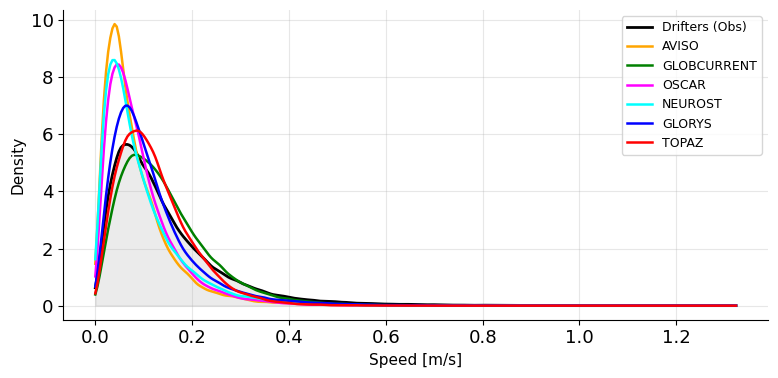

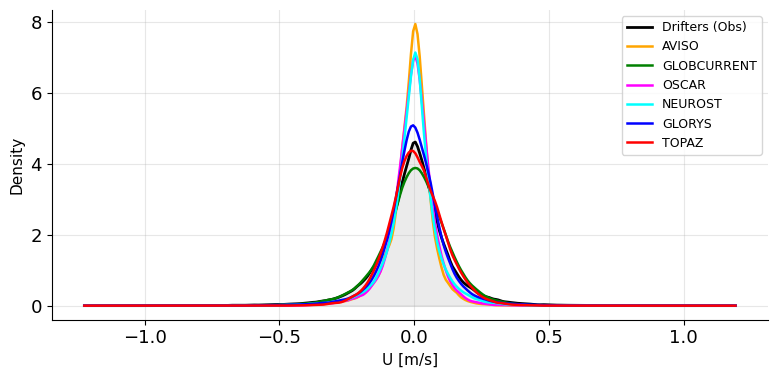

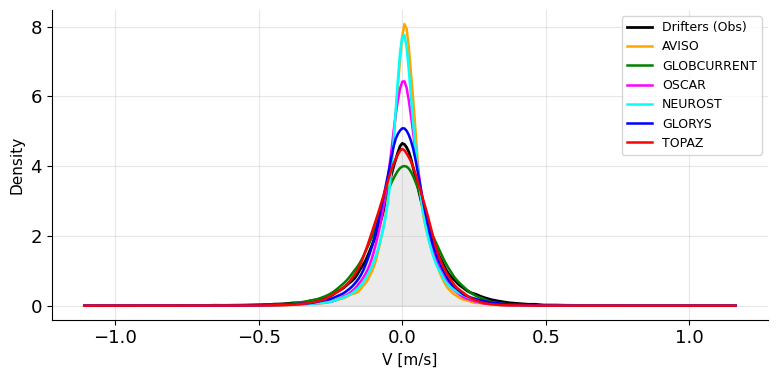

In [20]:
# 1. Definim la paleta elèctrica/fluorescent global (afegeix-la a l'inici del teu script)
MODEL_COLORS = {
    'AVISO': 'orange',        # Taronja Neó
    'GLOBCURRENT': 'green',  # Turquesa / Teal Elèctric
    'OSCAR': 'magenta',        # Blau Elèctric Viu
    'NEUROST': 'cyan',      # Violeta / Lila Elèctric
    'GLORYS': 'blue',       # Fúcsia / Rosa Xiclet
    'TOPAZ': 'red'         # Per si de cas al DF es diu només 'TOPAZ'
}

# 2. Funció de plot optimitzada
def plot_distributions(df):
    """KDE distributions of obs vs model, one figure per variable."""
    df_clean = df.dropna(subset=["u_obs", "v_obs", "speed_obs"]).copy()
    variables = [
        ("speed_obs", "speed_model", "Speed [m/s]"),
        ("u_obs",     "u_model",     "U [m/s]"),
        ("v_obs",     "v_model",     "V [m/s]"),
    ]
    models = list(df_clean["model_name"].unique())

    for obs_col, mod_col, xlabel in variables:
        fig, ax = plt.subplots(figsize=(8, 4))

        obs_vals = df_clean[obs_col].dropna().values
        x_range  = np.linspace(obs_vals.min(), obs_vals.max(), 300)

        # Observations KDE (black)
        kde_obs = gaussian_kde(obs_vals)
        ax.plot(x_range, kde_obs(x_range), "k-", lw=2, label="Drifters (Obs)")
        ax.fill_between(x_range, kde_obs(x_range), alpha=0.08, color="k")

        # Model KDEs
        for model in models:
            subset   = df_clean[df_clean["model_name"] == model]
            mod_vals = subset[mod_col].dropna().values
            if len(mod_vals) < 10:
                continue
            
            # Busquem el color al diccionari. Si no el troba, posarà un gris fosc ('#555555')
            color_linea = MODEL_COLORS.get(model, "#555555")
            
            kde_mod = gaussian_kde(mod_vals)
            ax.plot(x_range, kde_mod(x_range), "-", color=color_linea,
                    lw=1.8, label=model)

        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel("Density", fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        plt.savefig(f"{OUTPUT_DIR}/distribution_{obs_col.replace('_obs', '')}.png", dpi=300)   
        plt.show()

# Trucada de la funció
plot_distributions(master_df)

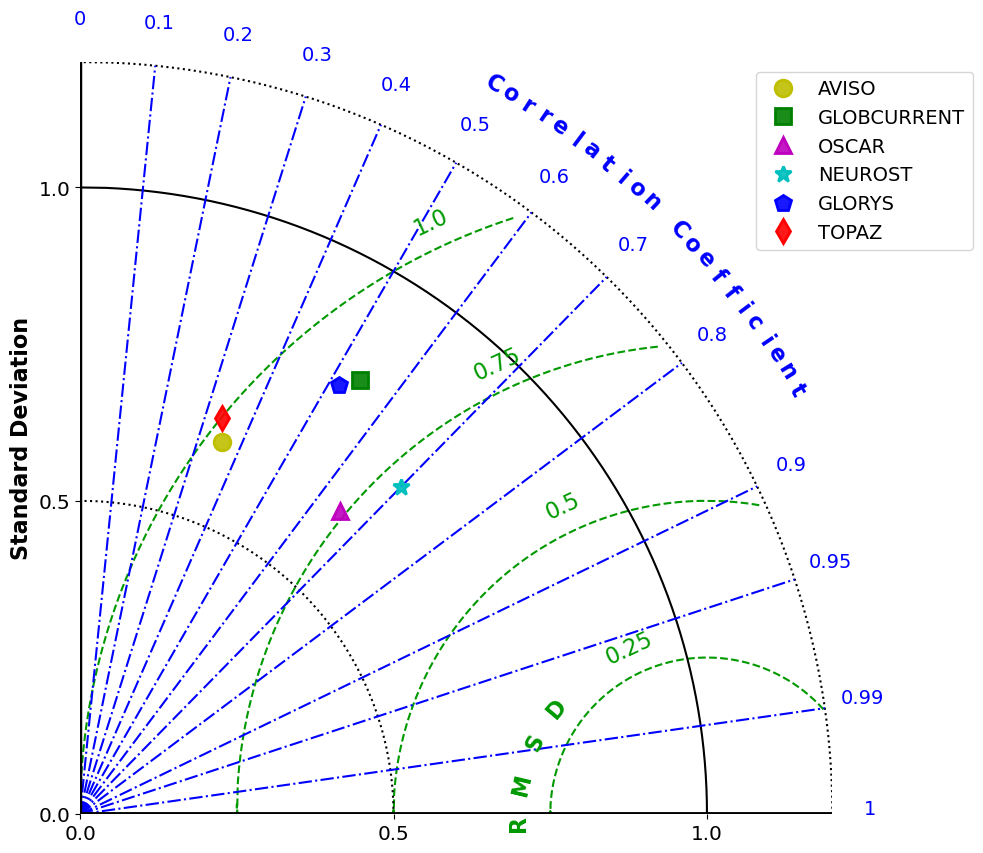

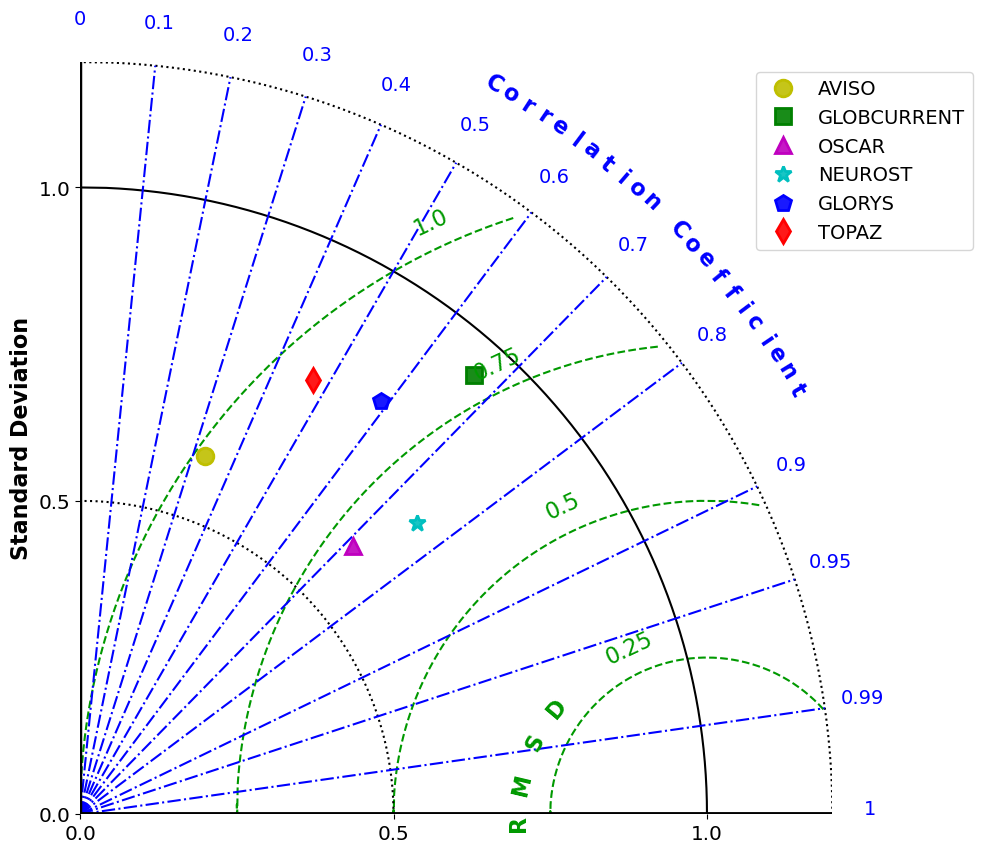

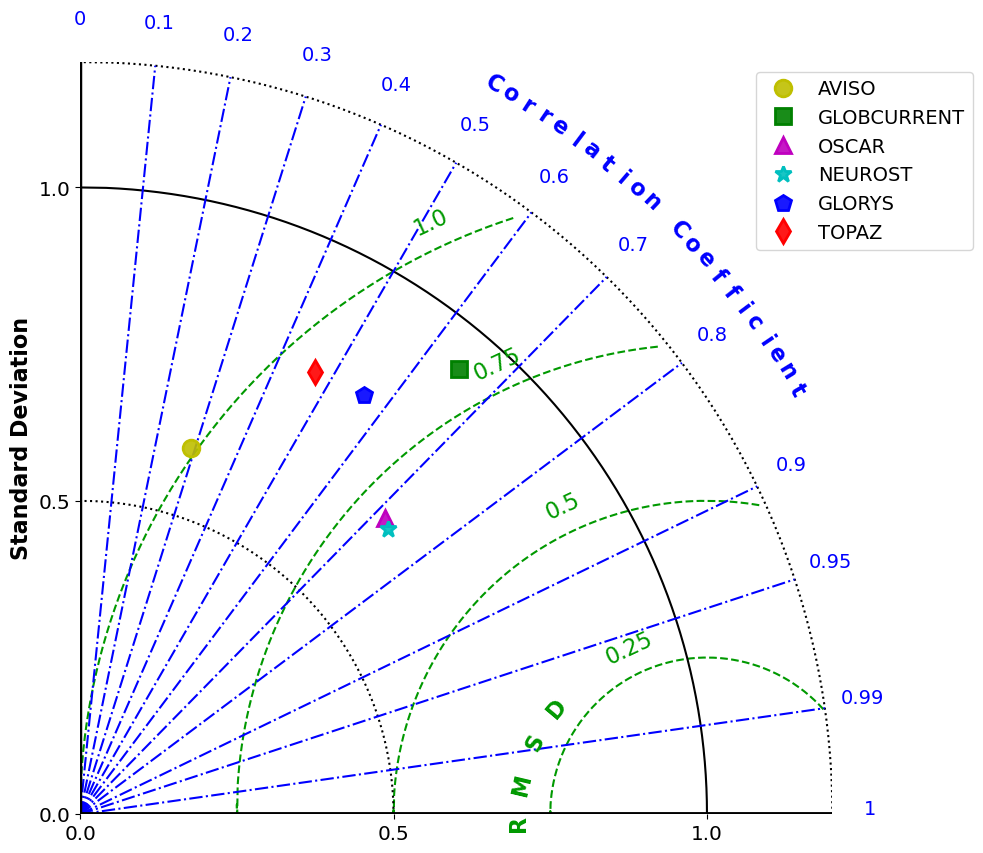

In [25]:
# Taylor diagrams 

def plot_taylor_arctic(df, variable_obs, variable_mod):
    """
    Taylor diagrams. Computes normalised statistics
    (STD, RMSE, Corr) per model vs drifters.
    """
    df_clean = df.dropna(subset=[variable_obs, variable_mod]).copy()
    models   = list(df_clean['model_name'].unique())

    # Reference STD from ALL observations
    std_ref = df_clean[variable_obs].std()

    # Build normalised statistics arrays: first entry = reference (Drifters)
    sdev  = [1.0]
    crmsd = [0.0]
    ccoef = [1.0]

    for model in models:
        subset = df_clean[df_clean['model_name'] == model]
        obs    = subset[variable_obs].values
        mod    = subset[variable_mod].values
        valid  = ~(np.isnan(obs) | np.isnan(mod))
        stats  = sm.taylor_statistics(mod[valid], obs[valid])
        sdev.append(stats['sdev'][1]  / std_ref)
        crmsd.append(stats['crmsd'][1] / std_ref)
        ccoef.append(stats['ccoef'][1])

    sdev  = np.array(sdev)
    crmsd = np.array(crmsd)
    ccoef = np.array(ccoef)
    
    fig = plt.figure(figsize=(9.5, 9))
    sm.taylor_diagram(sdev, crmsd, ccoef,
                      markerLabel      = ['Drifters (Ref)'] + models,
                      markerLegend     = 'on',
                      markerLabelColor = 'black',
                      markerSize       = 12,
                      default_colors   = ['y', 'g', 'm', 'c', 'b','r'],
                      default_markers  = ['o', 's', '^', '*', 'p','d'],
                      tickRMS          = [0.25, 0.5, 0.75, 1.0],
                      tickRMSangle     = 115,
                      showlabelsRMS    = 'on',
                      titleRMS         = 'on',
                      titleSTD         = 'on',
                      titleCOR         = 'on',
                      tickSTD          = [0.5, 1.0],
                      axismax          = 1.2,
                      alpha            = 0.9)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/taylor_{variable_obs.replace('_obs', '')}.png", dpi=300)
    plt.show()

plot_taylor_arctic(master_df, 'speed_obs', 'speed_model')
plot_taylor_arctic(master_df, 'u_obs',     'u_model')
plot_taylor_arctic(master_df, 'v_obs',     'v_model')

🌀 Computing polar directional error profiles per model...
🚀 Master polar profile plot saved at: /Users/jcreest/Documents/FRESH-CARE/WP1/outputs/polar_directional_error_profiles.png


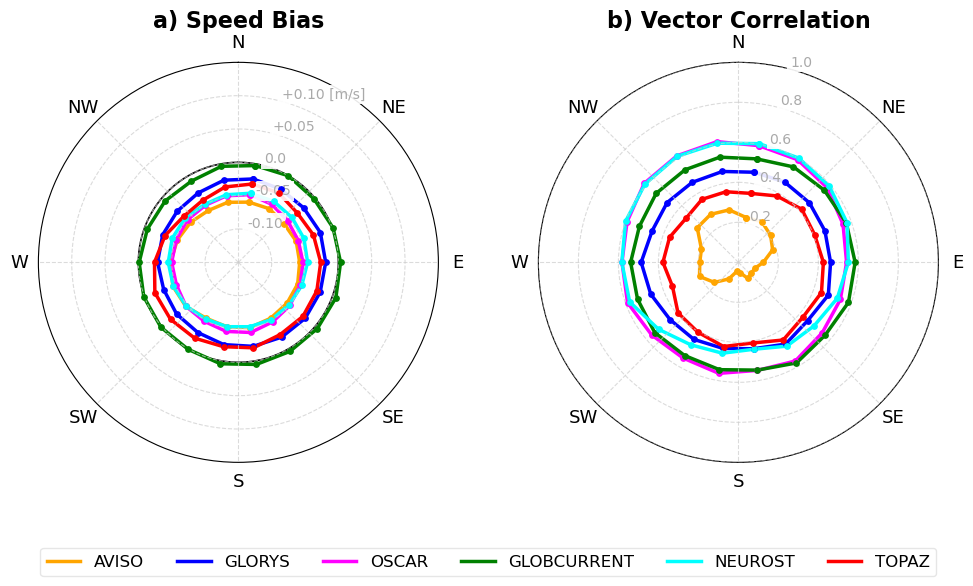

In [32]:
def plot_polar_directional_error_profiles(df, save_name="polar_directional_error_profiles.png"):
    """
    Generates a publication-grade 1x2 POLAR LINE panel using global font sizes.
    Plots systematic speed bias and vector correlation as a continuous 
    angular function (0-360°) for all models simultaneously.
    """
    import numpy as np
    import pandas as pd
    import os
    import matplotlib.pyplot as plt
    
    plt.rcParams.update({
        'font.size': 14,          
        'axes.labelsize': 16,     
        'axes.titlesize': 16,     
        'xtick.labelsize': 13,    
        'ytick.labelsize': 13,    
        'legend.fontsize': 12,    
        'figure.titlesize': 18,   
        'font.family': 'sans-serif',
        'text.usetex': False      
    })

    model_colors = {
        'AVISO': 'orange',        
        'GLOBCURRENT': 'green',  
        'OSCAR': 'magenta',       
        'NEUROST': 'cyan',     
        'GLORYS': 'blue',  
        'TOPAZ': 'red' 
    }

    bin_size = 20
    dir_bins = np.arange(0, 361, bin_size)
    bin_centers = dir_bins[:-1] + (bin_size / 2)
    theta_radians = np.radians(bin_centers)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 7), subplot_kw={'projection': 'polar'})

    print("🌀 Computing polar directional error profiles per model...")

    for model_name in ['AVISO', 'GLORYS', 'OSCAR', 'GLOBCURRENT', 'NEUROST', 'TOPAZ']:
        subset = df[df['model_name'] == model_name].copy()
        subset = subset.dropna(subset=['u_obs', 'v_obs', 'u_model', 'v_model'])
        
        if subset.empty: continue

        # Metrics computation
        subset['speed_obs_calc']   = np.sqrt(subset['u_obs']**2   + subset['v_obs']**2)
        subset['speed_model_calc'] = np.sqrt(subset['u_model']**2 + subset['v_model']**2)
        subset['speed_diff_calc']  = subset['speed_model_calc'] - subset['speed_obs_calc']
        
        dot = subset['u_obs'] * subset['u_model'] + subset['v_obs'] * subset['v_model']
        mag_o = subset['speed_obs_calc'].replace(0, np.nan)
        mag_m = subset['speed_model_calc'].replace(0, np.nan)
        subset['vec_corr_calc'] = dot / (mag_o * mag_m)
        
        # Ref direction
        subset['dir_obs_calc'] = np.degrees(np.arctan2(subset['u_obs'], subset['v_obs'])) % 360
        subset['dir_bin'] = pd.cut(subset['dir_obs_calc'], bins=dir_bins, labels=bin_centers)

        # Stats
        stats = subset.groupby('dir_bin', observed=False).agg(
            bias_mean=('speed_diff_calc', 'mean'),
            corr_mean=('vec_corr_calc', 'mean')
        )

        r_bias = list(stats['bias_mean'].values)
        r_bias.append(r_bias[0])
        
        r_corr = list(stats['corr_mean'].values)
        r_corr.append(r_corr[0])
        
        theta_plot = np.append(theta_radians, theta_radians[0])
        color = model_colors[model_name]

        ax1.plot(theta_plot, r_bias, color=color, linewidth=2.5, label=model_name)
        ax1.scatter(theta_plot, r_bias, color=color, s=15, zorder=3)

        ax2.plot(theta_plot, r_corr, color=color, linewidth=2.5)
        ax2.scatter(theta_plot, r_corr, color=color, s=15, zorder=3)

    for ax in [ax1, ax2]:
        ax.set_theta_zero_location('N')  
        ax.set_theta_direction(-1)
        ax.set_thetagrids([0, 45, 90, 135, 180, 225, 270, 315], 
                          ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
        ax.grid(True, linestyle='--', color='#cccccc', alpha=0.7)

    ax1.set_rlim(-0.15, 0.15)
    ax1.set_rticks([-0.10, -0.05, 0.0, 0.05, 0.10])
    
    ax1.set_rlabel_position(15) 
    
    ticks_a = ax1.set_yticklabels(['-0.10', '-0.05', '0.0', '+0.05', '+0.10 [m/s]'], color='darkgray',fontsize=10)
    for t in ticks_a:
        t.set_zorder(10)
        t.set_bbox(dict(facecolor='white', alpha=0.9, edgecolor='none', pad=2, zorder=10))

    ax1.plot(np.linspace(0, 2*np.pi, 100), np.zeros(100), color='black', linestyle='-', linewidth=1.2, zorder=1)
    ax1.set_title('a) Speed Bias', fontweight='bold', pad=25)

    ax2.set_rlim(0.0, 1.0)
    ax2.set_rticks([0.2, 0.4, 0.6, 0.8, 1.0])
    
    ax2.set_rlabel_position(15)
    
    ticks_b = ax2.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], color='darkgray',fontsize=10)
    for t in ticks_b:
        t.set_zorder(10)
        t.set_bbox(dict(facecolor='white', alpha=0.9, edgecolor='none', pad=2, zorder=10))
        
    ax2.set_title('b) Vector Correlation', fontweight='bold', pad=25)

    ax1.set_axisbelow(False)
    ax2.set_axisbelow(False)
    
    # Shared legend
    fig.legend(loc='lower center', bbox_to_anchor=(0.5, 0.04), frameon=True, 
               facecolor='white', edgecolor='#e0e0e0', ncol=6)
    fig.subplots_adjust(left=0.05, right=0.95, top=0.82, bottom=0.18, wspace=0.25)
    
    # Save
    full_output_path = os.path.join(OUTPUT_DIR, save_name)
    plt.savefig(full_output_path, dpi=300, bbox_inches='tight')
    plt.show()

# Execute
plot_polar_directional_error_profiles(master_df)